In [1]:
from data.dataset import DOGVideoREIDDataset
from configs.config import Config
from data.transforms import ViTVideoTransform
from torch.utils.data import DataLoader
from pytorch_metric_learning.samplers import MPerClassSampler
cfg = Config()

In [2]:

train_dataset = DOGVideoREIDDataset(
    root_dir=cfg.data_root,
    split_file=cfg.split_file,
    split="train",
    world=cfg.world,
    clip_len=cfg.clip_len,
    transform=ViTVideoTransform()
)


query_dataset = DOGVideoREIDDataset(
    root_dir=cfg.data_root,
    split_file=cfg.split_file,
    split="query",
    world=cfg.world,
    clip_len=cfg.clip_len,
    transform=ViTVideoTransform()
)

sampler = MPerClassSampler(
    labels=train_dataset.labels,  
    m=2                     
)

In [3]:
print("Dataset size:", len(train_dataset))

clip, label, dog_id, video_id = train_dataset[64]

print("Clip shape:", clip.shape)
print("Label:", label)
print("Dog ID:", dog_id)
print("Video ID:", video_id)

Dataset size: 3756
Clip shape: torch.Size([1, 3, 224, 224])
Label: 10
Dog ID: 0306db0b-0e06-4343-ab9d-ea3ec4777d9a
Video ID: 5d56638a-aeb2-47b4-ba1f-57fa588df005


In [4]:
print("Dataset size:", len(query_dataset))

clip, label, dog_id, video_id = query_dataset[43]

print("Clip shape:", clip.shape)
print("Label:", label)
print("Dog ID:", dog_id)
print("Video ID:", video_id)

Dataset size: 1594
Clip shape: torch.Size([1, 3, 224, 224])
Label: 16
Dog ID: 0452d596-3bf1-41fa-a7df-60b5be8db69f
Video ID: 496bccbe-ed3d-48fb-9319-bf1cca92a793


In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,   # must = num_ids * num_instances
    sampler=sampler,
    num_workers=4,
    drop_last=True
)

query_loader = DataLoader(
    query_dataset,
    batch_size=cfg.batch_size,   # must = num_ids * num_instances
    sampler=sampler,
    num_workers=4,
    drop_last=True
)

In [6]:
len(train_loader)

24924

In [7]:
import matplotlib.pyplot as plt
import torch

batch = next(iter(train_loader))
clips, labels, dog_ids, video_ids = batch
print(dog_ids)


('e3088147-d545-46f0-89cf-7ebc352ffce2', 'e3088147-d545-46f0-89cf-7ebc352ffce2', 'a637e0c9-75fc-490e-abe7-79944e7d0937', 'a637e0c9-75fc-490e-abe7-79944e7d0937')


here


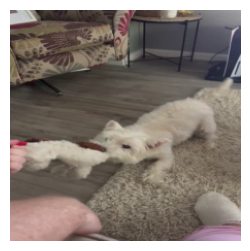

In [8]:
clip = clips[1]   # (T, C, H, W)

mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

T = clip.shape[0]

fig, axes = plt.subplots(1, T, figsize=(3*T,3))

# ensure axes is iterable
if T == 1:
    axes = [axes]
    print("here")

for i in range(T):
    frame = clip[i]

    frame = frame * std + mean
    frame = frame.permute(1,2,0)

    axes[i].imshow(frame.numpy())
    axes[i].axis("off")

plt.show()

In [9]:
import torch

def compute_similarity_matrix(self, qf, gf):

    qf = torch.nn.functional.normalize(qf, dim=1)
    gf = torch.nn.functional.normalize(gf, dim=1)

    sim_mat = qf @ gf.T

    return sim_mat


def compute_metrics(self, similarity_mat, query_labels, gallery_labels):

    query_labels = torch.tensor(query_labels)
    gallery_labels = torch.tensor(gallery_labels)

    num_queries = len(query_labels)
    num_gallery = len(gallery_labels)

    cmc_curve = torch.zeros(num_gallery)

    ap_list = []

    print(similarity_mat.shape)
    print(len(query_labels), len(gallery_labels))

    for query_label, similarity_row in zip(query_labels, similarity_mat):

        sorted_indices = torch.argsort(similarity_row, descending=True)

        matches = (gallery_labels[sorted_indices] == query_label).float()

        if matches.sum() == 0:
            continue

        rank = matches.nonzero(as_tuple=False)[0].item()

        cmc_curve[rank:] += 1

        cum_matches = matches.cumsum(0)

        precision_at_k = cum_matches / torch.arange(
            1, num_gallery + 1, dtype=torch.float32
        )

        ap = (precision_at_k * matches).sum() / matches.sum()

        ap_list.append(ap)

    cmc_curve = cmc_curve / num_queries

    mAP = torch.stack(ap_list).mean().item()

    return cmc_curve, mAP

In [13]:
import torch

# 3 queries, 5 gallery items
query_labels = [0, 1, 2]
gallery_labels = [0, 1, 2, 3, 4]

# fake similarity (force correct ranking)
similarity_mat = torch.tensor([
    [0, 0.1, 0.2, 0.4, 0.0],  # query 0 → best match index 0
    [0.1, 0.9, 0.2, 0.0, 0.0],  # query 1 → index 1
    [0.1, 0.9, 0.4, 0.0, 0.0],  # query 2 → index 2
])

cmc, mAP = compute_metrics(None, similarity_mat, query_labels, gallery_labels)

print("CMC:", cmc)
print("mAP:", mAP)

torch.Size([3, 5])
3 5
CMC: tensor([0.3333, 0.6667, 0.6667, 1.0000, 1.0000])
mAP: 0.5833333134651184


In [12]:
cfg = Config()
print(cfg.device)

cpu


In [ ]:
import torch

from configs.config import Config
from data.dataloader import build_dataloaders
from models.model_factory import build_model
from engine.trainer import Trainer


def main():

    # Load configuration
    cfg = Config()

    print(f"Evaluating with model: {cfg.model}")

    # Build dataloaders
    # train_loader is unused but returned by the function
    train_loader, query_loader, gallery_loader = build_dataloaders(cfg)

    # Build pretrained model
    model = build_model(cfg)

    # Optimizer not needed for evaluation, but Trainer expects it
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay
    )

    # Create trainer
    trainer = Trainer(
        model=model,
        train_loader=train_loader,
        query_loader=query_loader,
        gallery_loader=gallery_loader,
        optimizer=optimizer,
        device=cfg.device,
        cfg=cfg
    )

    # Run evaluation
    rank1, rank5, mAP = trainer.evaluate()

    print("\nEvaluation Results")
    print(f"Rank-1: {rank1:.4f}")
    print(f"Rank-5: {rank5:.4f}")
    print(f"mAP: {mAP:.4f}")


if __name__ == "__main__":
    main()

Evaluating with model: vit
evaluating


Extracting query features:   0%|          | 0/200 [00:00<?, ?it/s]/d/hpc/home/mm12755/.conda/envs/project/lib/python3.13/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/d/hpc/projects/FRI/mm12755/DogReID-1553/DogReID-1553/engine/trainer.py:146: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():
/d/hpc/home/mm12755/.conda/envs/project/lib/python3.13/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Extracting query features:  25%|██▌       | 50/200 [03:54<11:27,  4.59s/it]